# Goal of this project



### Background (collected data)
1. Raw video
2. Keypoints tracking by SLEAP (.h and .slp)
3. ephys data (4-shank Neuropixels)

### What this script for:
1. Extract head centroid from the sleap inference output
2. Smooth the trajectory (remove jitter)
3. Interpolate missing frames (if any)
4. Calculate relevant behavioral metrics (e.g., speed, acceleration, distance traveled)
5. Export the frame-to-frame data

### prerequisite
Install "movement" package
see https://movement.neuroinformatics.dev/latest/user_guide/installation.html


In [41]:
# Import necessary packages

import movement
from movement.io import load_dataset
from movement.filtering import filter_by_confidence, interpolate_over_time, rolling_filter, savgol_filter
from movement.kinematics import compute_velocity, compute_forward_vector, compute_forward_vector_angle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from movement.plots import plot_centroid_trajectory
from movement.utils.vector import cart2pol, pol2cart
from scipy.signal import welch

print("Successfully imported packages, happy coding!")

Successfully imported packages, happy coding!


In [11]:
# Loading sleap inference data (.h5 / .slp)

## Change to your own project path
project_root_yjl = r"/Users/jialin/Documents/PhD_CodeBase/course-animals-in-motion/github_collaboration/Prototype-for-integrating-movement-SpikeInterface-and-pynapple-OSSS2026-/"
project_root_evan = r"C:/Users/moffi/Documents/UCL/Sainsbury Wellcome Centre/OSSS/Hackathon data"
project_root = ""
#

slp_file_name = "T1_1D_04032026_inference.slp"
h5_file_name = "T1_1D_04032026.h5"

## choose your project root
file_dir = Path(project_root_yjl)
file_name = h5_file_name
file_path = Path(file_dir)/"data"/"SLEAP_data(behavior)"/file_name

## check file exists or not
if file_path.exists():
    print(f"loading: {file_name}")
else:
    raise FileNotFoundError(f"File not found: {file_path}")

# loading single filedata
ds=load_dataset(file_path, fps=25)

loading: T1_1D_04032026.h5


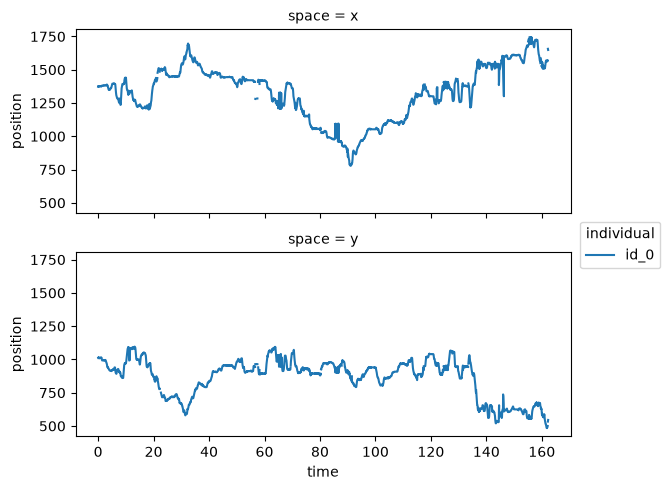

In [14]:
ds_headcap = ds.sel(keypoint=["headcap"])
#visualise headcap position across space
headcap_pos=ds.position.sel(keypoint="headcap")
headcap_pos.plot.line(x="time", hue="individual", row="space", aspect=2, size=2.5)

50% confidence: 0.9201700687408447
75% confidence: 0.9476786702871323


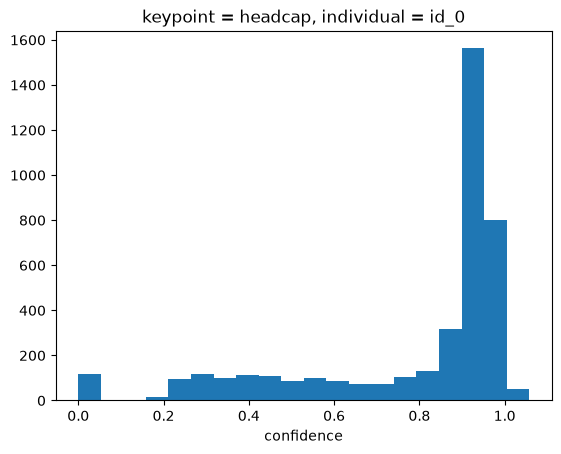

In [15]:
#Inspect outliers
ds_headcap.confidence.squeeze().plot.hist(bins=20,)

q1, q2 = np.nanpercentile(ds_headcap.confidence.squeeze(), [50, 75])

print(f"50% confidence: {q1}")
print(f"75% confidence: {q2}")

Missing points (marked as NaN) in input:

keypoint                 snout           right_ear           left_ear           center             headcap
individual                                                                                                
id_0        4125/4135 (99.76%)  1184/4135 (28.63%)  1311/4135 (31.7%)  77/4135 (1.86%)  1179/4135 (28.51%)
Missing points (marked as NaN) in output:

keypoint                 snout          right_ear           left_ear           center            headcap
individual                                                                                              
id_0        4125/4135 (99.76%)  605/4135 (14.63%)  558/4135 (13.49%)  77/4135 (1.86%)  559/4135 (13.52%)
Missing points (marked as NaN) in input:

keypoint                 snout          right_ear           left_ear           center            headcap
individual                                                                                              
id_0        4125/4135 (99.7

Text(0.5, 0.98, 'Headcap position across space: original, filtered, and interpolated')

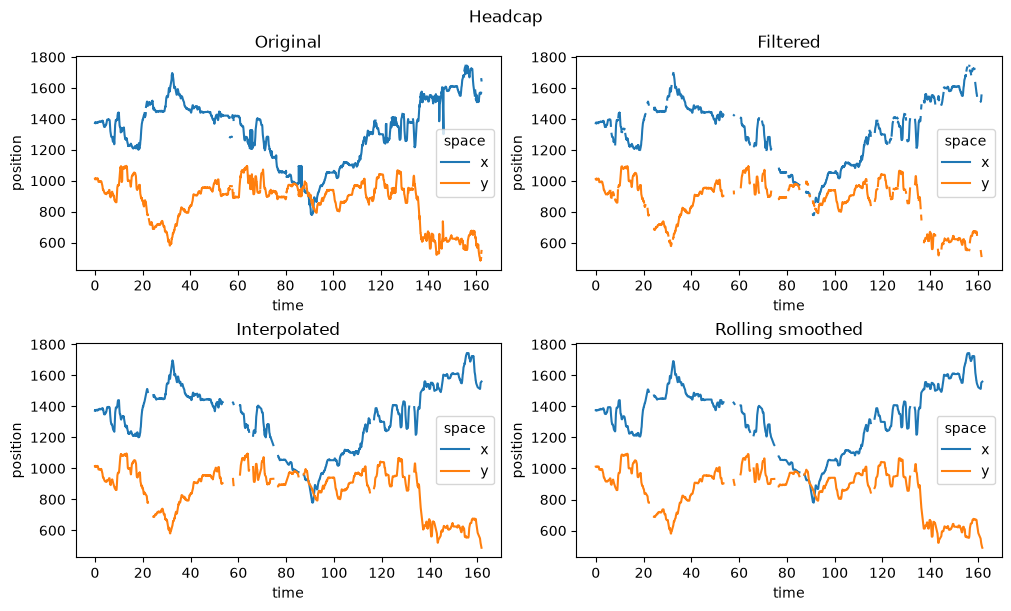

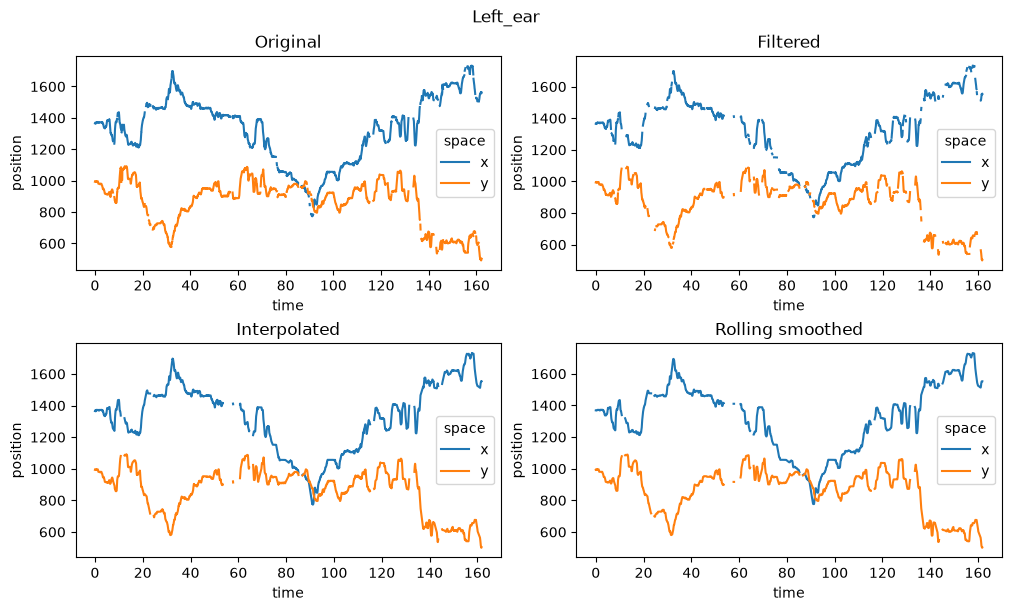

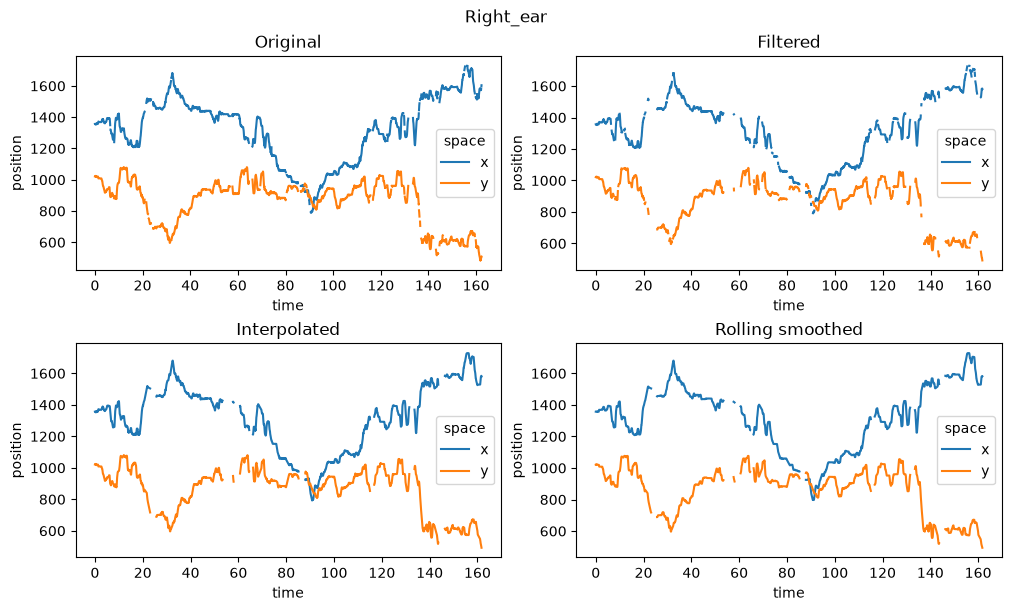

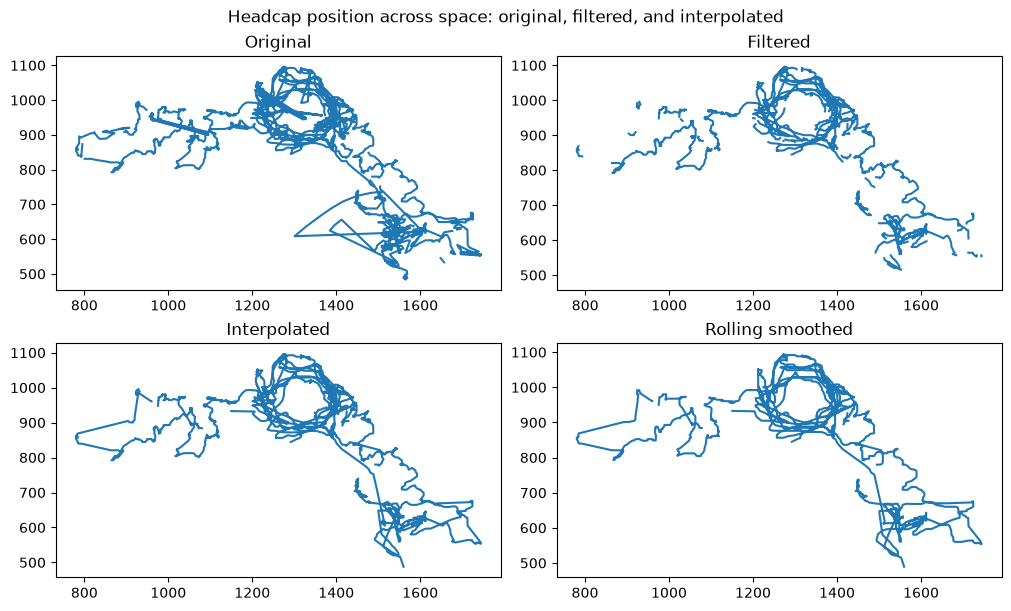

In [30]:
#Filter outliers, interpolate, and rolling smooth

# since the 75% confidence is around 0.9, why we select 0.9 or 0.8 as the threshold for filtering out low confidence data points. 

ds_pos = ds.copy()

ds_rm_LowConf = filter_by_confidence(
    ds_pos.position, ds_pos.confidence, threshold=0.75, print_report=False)

#Interpolate filtered data
ds_interpolated = interpolate_over_time(
    ds_rm_LowConf,max_gap=35,print_report=True)

window=int(0.3*ds.fps)
ds_rolling = rolling_filter(
    ds_interpolated, window=window, min_periods=2, statistic="median", print_report=True
)


# timeseries plot of headcap position (x,y)
## headcap
fig, ax = plt.subplots(ncols=2, nrows = 2, figsize=(10, 6),constrained_layout=True)
ds_pos.position.sel(keypoint=['headcap']).squeeze().plot.line(x="time", hue="space",ax = ax[0,0])
ax[0,0].set_title("Original")
ds_rm_LowConf.sel(keypoint=['headcap']).squeeze().plot.line(x="time", hue="space",ax = ax[0,1])
ax[0,1].set_title("Filtered")
ds_interpolated.sel(keypoint=['headcap']).squeeze().plot.line(x="time", hue="space",ax = ax[1,0])
ax[1,0].set_title("Interpolated")
ds_rolling.sel(keypoint=['headcap']).squeeze().plot.line(x="time", hue="space",ax = ax[1,1])
ax[1,1].set_title("Rolling smoothed")
fig.suptitle("Headcap")

## left_ear
fig, ax = plt.subplots(ncols=2, nrows = 2, figsize=(10, 6),constrained_layout=True)
ds_pos.position.sel(keypoint=['left_ear']).squeeze().plot.line(x="time", hue="space",ax = ax[0,0])
ax[0,0].set_title("Original")
ds_rm_LowConf.sel(keypoint=['left_ear']).squeeze().plot.line(x="time", hue="space",ax = ax[0,1])
ax[0,1].set_title("Filtered")
ds_interpolated.sel(keypoint=['left_ear']).squeeze().plot.line(x="time", hue="space",ax = ax[1,0])
ax[1,0].set_title("Interpolated")
ds_rolling.sel(keypoint=['left_ear']).squeeze().plot.line(x="time", hue="space",ax = ax[1,1])
ax[1,1].set_title("Rolling smoothed")
fig.suptitle("Left_ear")

## right_ear
fig, ax = plt.subplots(ncols=2, nrows = 2, figsize=(10, 6),constrained_layout=True)
ds_pos.position.sel(keypoint=['right_ear']).squeeze().plot.line(x="time", hue="space",ax = ax[0,0])
ax[0,0].set_title("Original")
ds_rm_LowConf.sel(keypoint=['right_ear']).squeeze().plot.line(x="time", hue="space",ax = ax[0,1])
ax[0,1].set_title("Filtered")
ds_interpolated.sel(keypoint=['right_ear']).squeeze().plot.line(x="time", hue="space",ax = ax[1,0])
ax[1,0].set_title("Interpolated")
ds_rolling.sel(keypoint=['right_ear']).squeeze().plot.line(x="time", hue="space",ax = ax[1,1])
ax[1,1].set_title("Rolling smoothed")
fig.suptitle("Right_ear")

# visualize the headcap position

fig, ax = plt.subplots(ncols=2, nrows = 2, figsize=(10, 6),constrained_layout=True)
ax[0,0].plot(ds_headcap_pos.squeeze().sel(space="x"), ds_headcap_pos.squeeze().sel(space="y"), label="Original", alpha=1,)
ax[0,0].set_title("Original")

ax[0,1].plot(ds_headcap_rm_LowConf.squeeze().sel(space="x"), ds_headcap_rm_LowConf.squeeze().sel(space="y"), label="Filtered", alpha=1,)
ax[0,1].set_title("Filtered")
ax[0,1].set_xlim()
ax[0,1].set_ylim()

ax[1,0].plot(ds_headcap_interpolated.squeeze().sel(space="x"), ds_headcap_interpolated.squeeze().sel(space="y"), label="Interpolated", alpha=1,)
ax[1,0].set_title("Interpolated")
ax[1,0].set_xlim()
ax[1,0].set_ylim()

ax[1,1].plot(ds_headcap_rolling.squeeze().sel(space="x"), ds_headcap_rolling.squeeze().sel(space="y"), label="Rolling smoothed", alpha=1,)
ax[1,1].set_title("Rolling smoothed")
ax[1,1].set_xlim()
ax[1,1].set_ylim()

fig.suptitle("Headcap position across space: original, filtered, and interpolated")



In [35]:
#Generate pipeline log

ds_smooth=ds.copy ()
ds_smooth.update({"position":ds_rolling})

print(ds_smooth.position.log)

[
  {
    "operation": "filter_by_confidence",
    "datetime": "2026-08-21 16:12:19.106049",
    "confidence": "<xarray.DataArray 'confidence' (time: 4135, keypoint: 5, individual: 1)> Size: 83kB\n0.0 0.9264 0.9678 0.9671 0.9351 0.0 0.9788 1.003 ... nan nan nan nan nan nan nan\nCoordinates:\n  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4\n  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'\n  * individual  (individual) <U4 16B 'id_0'",
    "threshold": "0.75",
    "print_report": "False"
  },
  {
    "operation": "interpolate_over_time",
    "datetime": "2026-08-21 16:12:19.138606",
    "method": "'linear'",
    "max_gap": "35",
    "print_report": "True"
  },
  {
    "operation": "rolling_filter",
    "datetime": "2026-08-21 16:12:19.150258",
    "window": "7",
    "statistic": "'median'",
    "min_periods": "2",
    "print_report": "True"
  }
]


2026-08-21 16:21:48.367 | WARNING  | matplotlib._api:warn_external:494 - /var/folders/rp/hz4sc_l50b34jqvg9v1mvpwm0000gn/T/ipykernel_55803/361155893.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



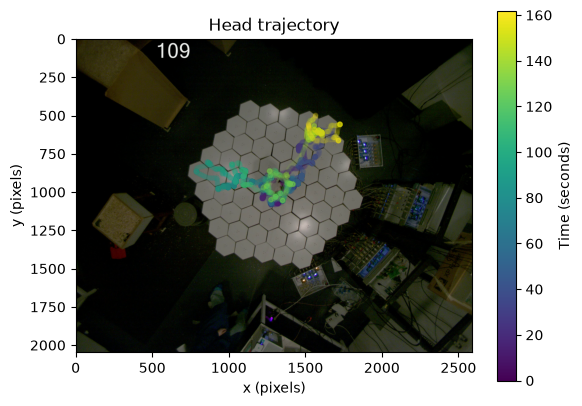

In [36]:
#compute head direction
##Visualise the head trajectory

frame_path= file_dir/ "vlcsnap-2026-08-21-15h13m03s667.png"
# Create figure and axis
fig, ax = plt.subplots(1, 1)

# Plot a single frame from the dataset (its path is stored as an attribute)
frame = plt.imread(frame_path)
ax.imshow(frame)

# Plot the trajectory of the head centre
plot_centroid_trajectory(
    ds_smooth.position,
    keypoints=["left_ear", "right_ear"],
    ax=ax,
    # arguments forwarded to plt.scatter
    s=10,
    cmap="viridis",
    marker="o",
    alpha=0.05,
)

# Adjust title
ax.set_title("Head trajectory")
ax.set_ylim(frame.shape[0], 0)  # match y-axis limits to image coordinates
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.collections[0].colorbar.set_label("Time (seconds)")
fig.show()

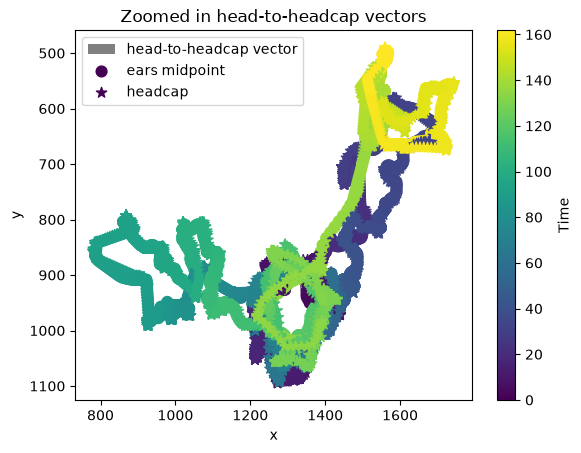

In [38]:
#Compute the head-to-headcap vector

# Compute the head centre as the midpoint between the ears
midpoint_ears = ds_smooth.position.sel(keypoint=["left_ear", "right_ear"]).mean(
    dim="keypoint"
)
# Snout position
# (`drop=True` removes the keypoint dimension, which is now redundant)
headcap = ds_smooth.position.sel(keypoint="headcap", drop=True)

# Compute the head vector as the difference vector between the snout position
# and the head-centre position.
head_to_headcap = headcap - midpoint_ears

# Time window to restrict the plot
time_window = slice(0, 1000)  # seconds

fig, ax = plt.subplots()

# Plot the computed head-to-snout vector originating from the ears midpoint
ax.quiver(
    midpoint_ears.sel(space="x", time=time_window),
    midpoint_ears.sel(space="y", time=time_window),
    head_to_headcap.sel(space="x", time=time_window),
    head_to_headcap.sel(space="y", time=time_window),
    color="gray",
    angles="xy",
    scale=1,
    scale_units="xy",
    headwidth=4,
    headlength=5,
    headaxislength=5,
    label="head-to-headcap vector",
)

# Plot midpoint between the ears within the time window
plot_centroid_trajectory(
    midpoint_ears.sel(time=time_window),
    ax=ax,
    s=60,
    label="ears midpoint",
)

# Plot the snout position within the time window
plot_centroid_trajectory(
    headcap.sel(time=time_window),
    ax=ax,
    s=60,
    marker="*",
    label="headcap",
)

# Calling plot_centroid_trajectory twice will add 2 identical colorbars
# so we remove 1
ax.collections[2].colorbar.remove()

ax.set_title("Zoomed in head-to-headcap vectors")
ax.invert_yaxis()  # invert y-axis to match image coordinates
ax.legend(loc="upper left")

Text(0.5, 1.0, 'Forward vector angle - head_to_headcap angle')

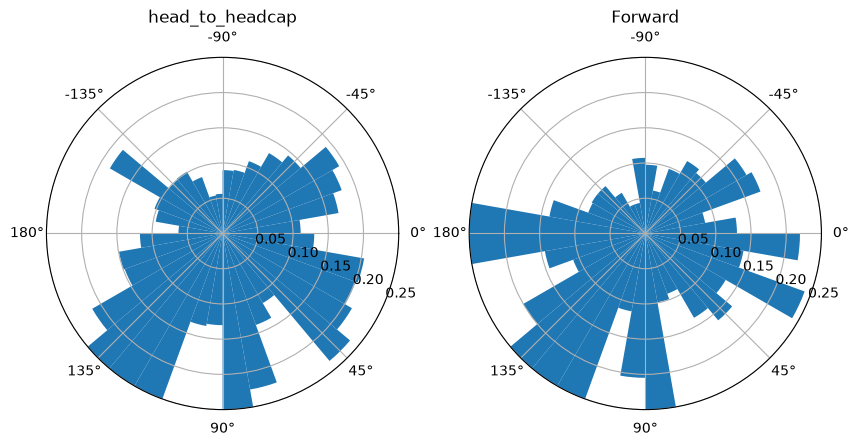

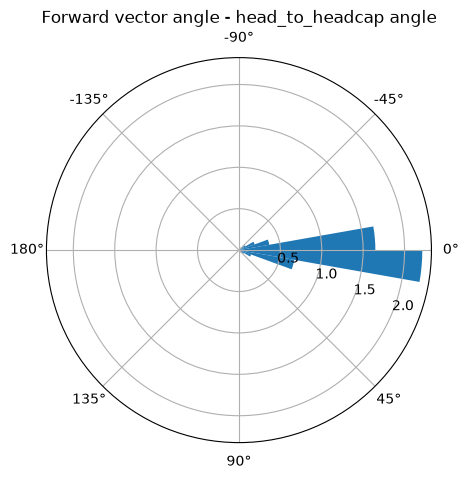

In [43]:
head_to_headcap_polar = cart2pol(head_to_headcap)
head_to_headcap_cart = pol2cart(head_to_headcap_polar)

forward_vector = compute_forward_vector(
    ds_smooth.position,
    left_keypoint="left_ear",
    right_keypoint="right_ear",
    camera_view="top_down",
)
forward_vector_angle = compute_forward_vector_angle(
    ds_smooth.position,
    left_keypoint="left_ear",
    right_keypoint="right_ear",
    # Optional parameters:
    reference_vector=(1, 0),  # positive x-axis
    camera_view="top_down",
    in_degrees=False,  # set to True for degrees
)

def plot_polar_histogram(da, bin_width_deg=15, ax=None):
    """Plot a polar histogram of the data in the given DataArray.

    Parameters
    ----------
    da : xarray.DataArray
        A DataArray containing angle data in radians.
    bin_width_deg : int, optional
        Width of the bins in degrees.
    ax : matplotlib.axes.Axes, optional
        The axes on which to plot the histogram.

    """
    n_bins = int(360 / bin_width_deg)

    if ax is None:
        fig, ax = plt.subplots(  # initialise figure with polar projection
            1, 1, figsize=(5, 5), subplot_kw={"projection": "polar"}
        )
    else:
        fig = ax.figure  # or use the provided axes

    # plot histogram using xarray's built-in histogram function
    da.plot.hist(
        bins=np.linspace(-np.pi, np.pi, n_bins + 1), ax=ax, density=True
    )

    # axes settings
    ax.set_theta_direction(-1)  # theta increases in clockwise direction
    ax.set_theta_offset(0)  # set zero at the right
    ax.set_xlabel("")  # remove default x-label from xarray's plot.hist()

    # set xticks to match the phi values in degrees
    n_xtick_edges = 9
    ax.set_xticks(np.linspace(0, 2 * np.pi, n_xtick_edges)[:-1])
    xticks_in_deg = (
        list(range(0, 180 + 45, 45)) + list(range(0, -180, -45))[-1:0:-1]
    )
    ax.set_xticklabels([str(t) + "\N{DEGREE SIGN}" for t in xticks_in_deg])

    return fig, ax


head_to_headcap_angle = head_to_headcap_polar.sel(space_pol="phi")
angle_arrays = [head_to_headcap_angle, forward_vector_angle]
angle_titles = ["head_to_headcap", "Forward"]

fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), subplot_kw={"projection": "polar"}
)
for i, angles in enumerate(angle_arrays):
    title = angle_titles[i]
    ax = axes[i]
    plot_polar_histogram(angles, bin_width_deg=10, ax=ax)
    ax.set_ylim(0, 0.25)  # force same y-scale (density) for both plots
    ax.set_title(title, pad=25)

angles_diff = forward_vector_angle - head_to_headcap_angle
fig, ax = plot_polar_histogram(angles_diff, bin_width_deg=10)
ax.set_title("Forward vector angle - head_to_headcap angle", pad=25)
